In [1]:
!pip install vaderSentiment

Looking in indexes: https://mirrors.bfsu.edu.cn/pypi/web/simple


In [25]:
import pandas as pd
import sqlite3
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

DB_PATH = "data/news/tech_news.db"
conn = sqlite3.connect(DB_PATH)
news_df = pd.read_sql("SELECT * FROM news", conn, parse_dates=["published"])

analyzer = SentimentIntensityAnalyzer()
def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    c = scores["compound"]
    if c >= 0.05:
        sentiment = "Positive"
    elif c <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    return pd.Series([sentiment, c, scores["pos"], scores["neu"], scores["neg"]])

news_df[["sentiment", "compound", "pos", "neu", "neg"]] = news_df["headline"].apply(get_vader_sentiment)
news_df.to_sql("news_with_sentiment", conn, if_exists="replace", index=False)
news_df.to_csv("data/news/tech_news_with_sentiment.csv", index=False)
print(news_df[["ticker", "headline", "sentiment", "compound", "pos", "neu", "neg"]].head(10))

conn.close()

  ticker                                           headline sentiment  \
0   AAPL  Apple supplier Jabil plans $500 million ventur...   Neutral   
1   AAPL  Ariana Grande's Grandmother Marjorie 'Nonna' G...  Negative   
2   AAPL  'F1' movie is thrilling, but is it authentic? ...  Positive   
3   AAPL           2024 INEOS Grenadier Fieldmaster Edition   Neutral   
4   AAPL  Todd Vande Hei Breaks Down the “Mismatch Theor...  Positive   
5   AAPL  The Trump Family Is Betting Big on Mobile Phon...  Negative   
6   AAPL  Still live: All four colors of the new 11-inch...   Neutral   
7   AAPL  This Jackery Explorer 1000 Portable Power Stat...  Positive   
8   AAPL  Techdirt Podcast Episode 422: The Political Po...  Negative   
9   AAPL  When Is ‘The Buccaneers’ Season 2 Coming Out? ...   Neutral   

   compound    pos    neu    neg  
0    0.0000  0.000  1.000  0.000  
1   -0.6486  0.000  0.650  0.350  
2    0.2617  0.136  0.864  0.000  
3    0.0000  0.000  1.000  0.000  
4    0.3818  0.133  0

In [26]:
DB_PATH = "data/news/tech_news.db"
conn = sqlite3.connect(DB_PATH)
news_df = pd.read_sql("SELECT * FROM news_with_sentiment", conn, parse_dates=["published"])
conn.close()

news_df['published'] = pd.to_datetime(news_df['published'], utc=True) # ensure time zone is UTC, then convert to US/Eastern
news_df['published_et'] = news_df['published'].dt.tz_convert('America/New_York')
news_df['date_et'] = news_df['published_et'].dt.date

agg = (
    news_df.groupby(['ticker', 'date_et'])
    .agg(
        mean_compound=('compound', 'mean'),
        mean_pos=('pos', 'mean'),
        mean_neu=('neu', 'mean'),
        mean_neg=('neg', 'mean'),
        n_headlines=('headline', 'count'),
        n_positive=('sentiment', lambda x: (x == 'Positive').sum()),
        n_neutral=('sentiment', lambda x: (x == 'Neutral').sum()),
        n_negative=('sentiment', lambda x: (x == 'Negative').sum())
    )
    .reset_index()
    .rename(columns={'date_et': 'date'})
)

agg['pct_positive'] = agg['n_positive'] / agg['n_headlines']
agg['pct_neutral']  = agg['n_neutral']  / agg['n_headlines']
agg['pct_negative'] = agg['n_negative'] / agg['n_headlines']
agg.to_csv('data/news/daily_sentiment_summary_et.csv', index=False)

print(agg.head(10))


  ticker        date  mean_compound  mean_pos  mean_neu  mean_neg  \
0   AAPL  2025-06-17       0.032370  0.070979  0.878392  0.050588   
1   AAPL  2025-06-22       0.039514  0.069187  0.877646  0.053156   
2   AAPL  2025-06-24       0.070060  0.085680  0.877082  0.037268   
3   AAPL  2025-06-25       0.062354  0.080354  0.870594  0.049063   
4   AAPL  2025-06-26       0.050358  0.075380  0.866380  0.058230   
5   AAPL  2025-06-27       0.091498  0.088828  0.863667  0.047515   
6   AAPL  2025-07-02       0.034907  0.074414  0.869293  0.056293   
7   AAPL  2025-07-07       0.142081  0.104947  0.861606  0.033426   
8   AAPL  2025-07-09       0.065702  0.089500  0.851167  0.059321   
9   AAPL  2025-07-10       0.122275  0.097750  0.840333  0.061917   

   n_headlines  n_positive  n_neutral  n_negative  pct_positive  pct_neutral  \
0           97          27         51          19      0.278351     0.525773   
1           96          27         52          17      0.281250     0.541667   


AAPL Merged Data Date Range: 2025-06-17 00:00:00 to 2025-07-10 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-17  195.639999       0.032370      0.278351           97
1 2025-06-24  200.300003       0.070060      0.257732           97
2 2025-06-25  201.559998       0.062354      0.322917           96
3 2025-06-26  201.000000       0.050358      0.350000          100
4 2025-06-27  201.080002       0.091498      0.363636           99
------------------------------------------------------------


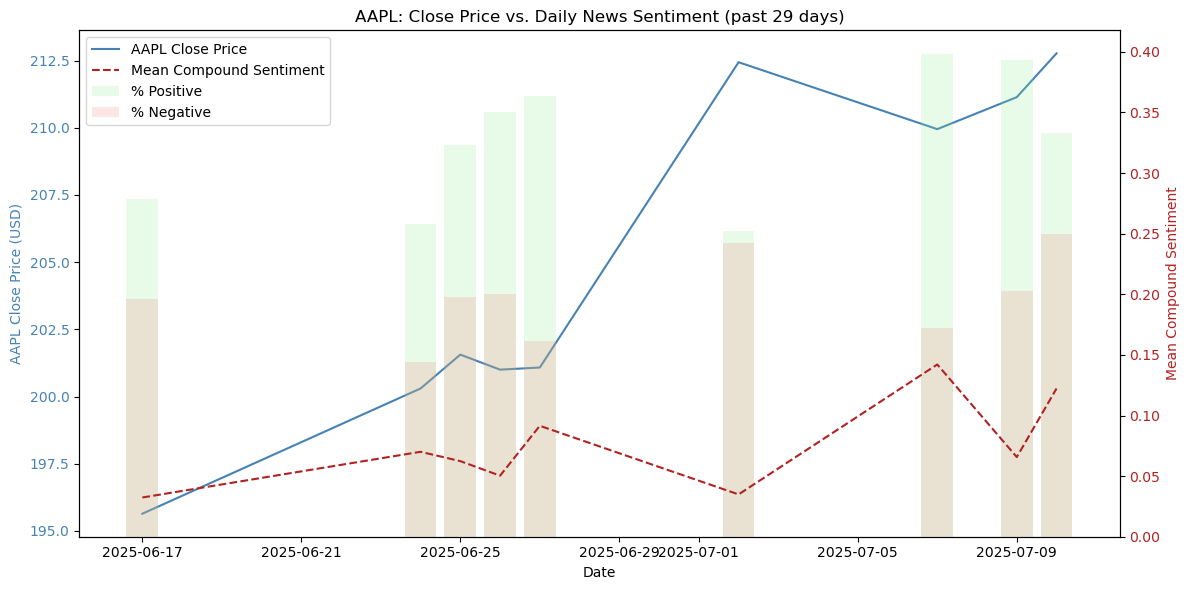

Saved and displayed plot for AAPL: image/AAPL_sentiment_vs_price.png
MSFT Merged Data Date Range: 2025-06-17 00:00:00 to 2025-07-10 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-17  478.040009      -0.058542      0.195876           97
1 2025-06-27  495.940002       0.009060      0.265306           98
2 2025-07-02  491.089996       0.038453      0.278351           97
3 2025-07-07  497.720001       0.014751      0.294737           95
4 2025-07-09  503.510010       0.047058      0.337079           89
------------------------------------------------------------


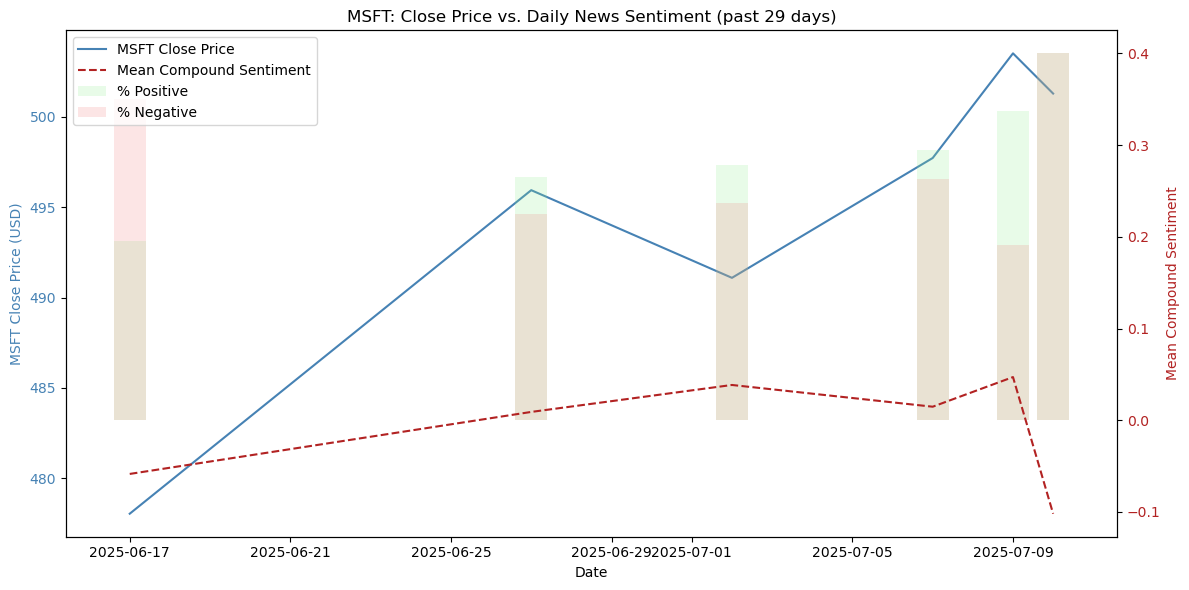

Saved and displayed plot for MSFT: image/MSFT_sentiment_vs_price.png
GOOGL Merged Data Date Range: 2025-06-16 00:00:00 to 2025-07-10 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-16  176.770004       0.025915      0.282828           99
1 2025-06-17  175.949997       0.036186      0.290000          100
2 2025-06-27  178.529999       0.062852      0.322917           96
3 2025-06-30  176.229996       0.026161      0.278351           97
4 2025-07-01  175.839996       0.014255      0.285714           98
------------------------------------------------------------


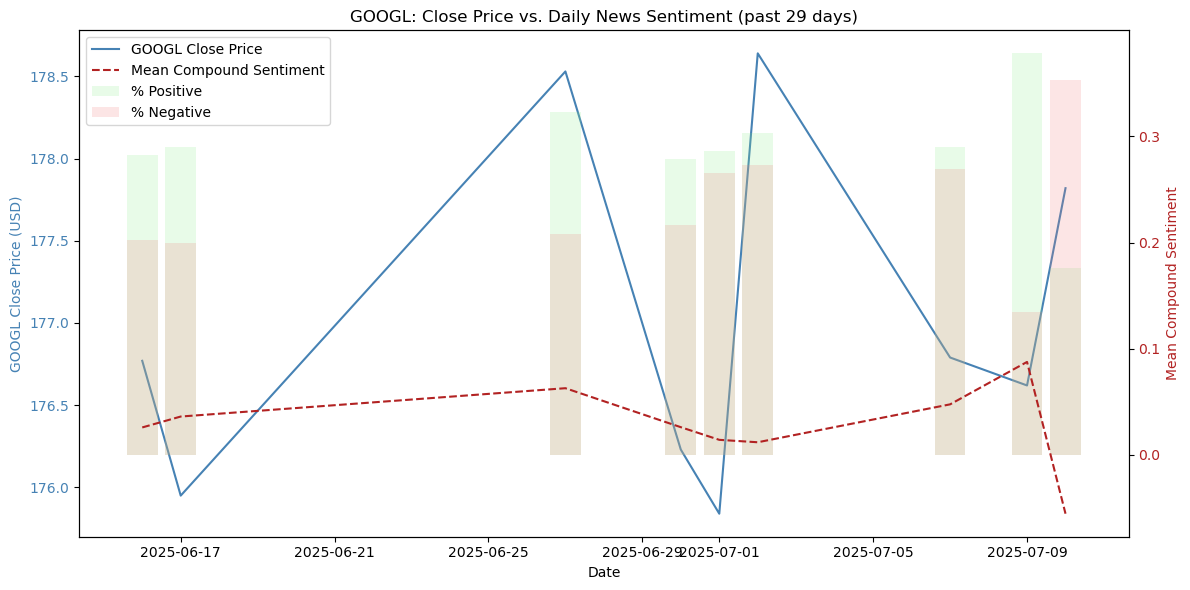

Saved and displayed plot for GOOGL: image/GOOGL_sentiment_vs_price.png
AMZN Merged Data Date Range: 2025-06-13 00:00:00 to 2025-07-10 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-13  212.100006       0.110881      0.464646           99
1 2025-06-16  216.100006       0.170286      0.515464           97
2 2025-06-17  214.820007       0.091211      0.490000          100
3 2025-06-27  223.300003       0.155715      0.483871           93
4 2025-07-02  219.919998       0.260567      0.595960           99
------------------------------------------------------------


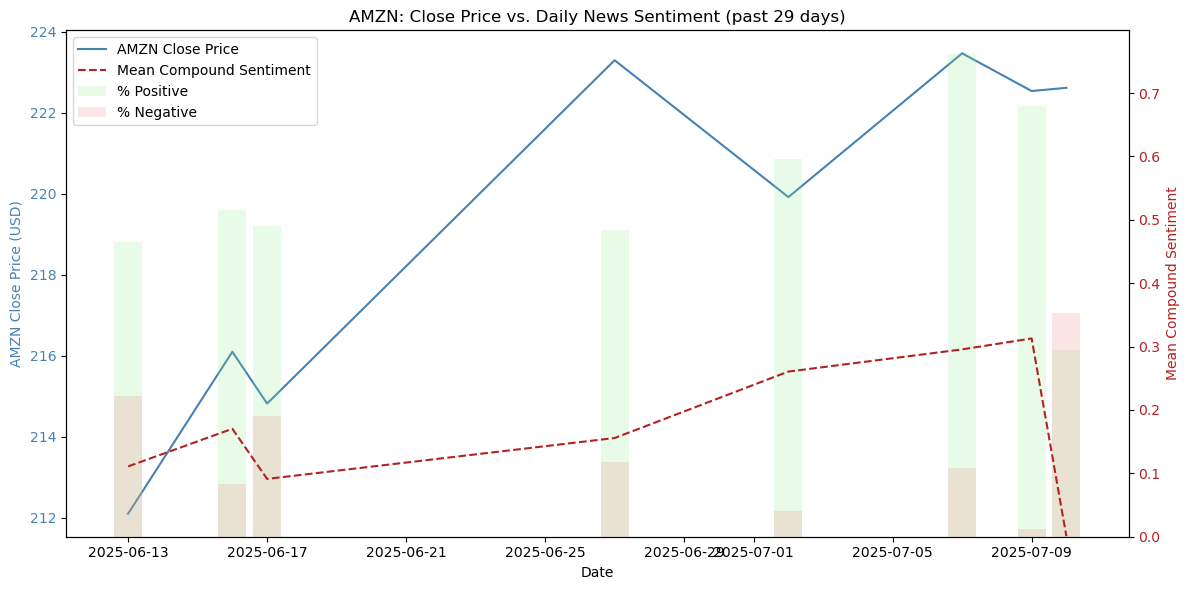

Saved and displayed plot for AMZN: image/AMZN_sentiment_vs_price.png
META Merged Data Date Range: 2025-06-17 00:00:00 to 2025-07-10 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-17  697.229980       0.048653      0.353535           99
1 2025-06-27  733.630005       0.039401      0.306122           98
2 2025-07-02  713.570007      -0.027145      0.333333           93
3 2025-07-07  718.349976      -0.018191      0.303030           99
4 2025-07-09  732.780029       0.004749      0.261905           84
------------------------------------------------------------


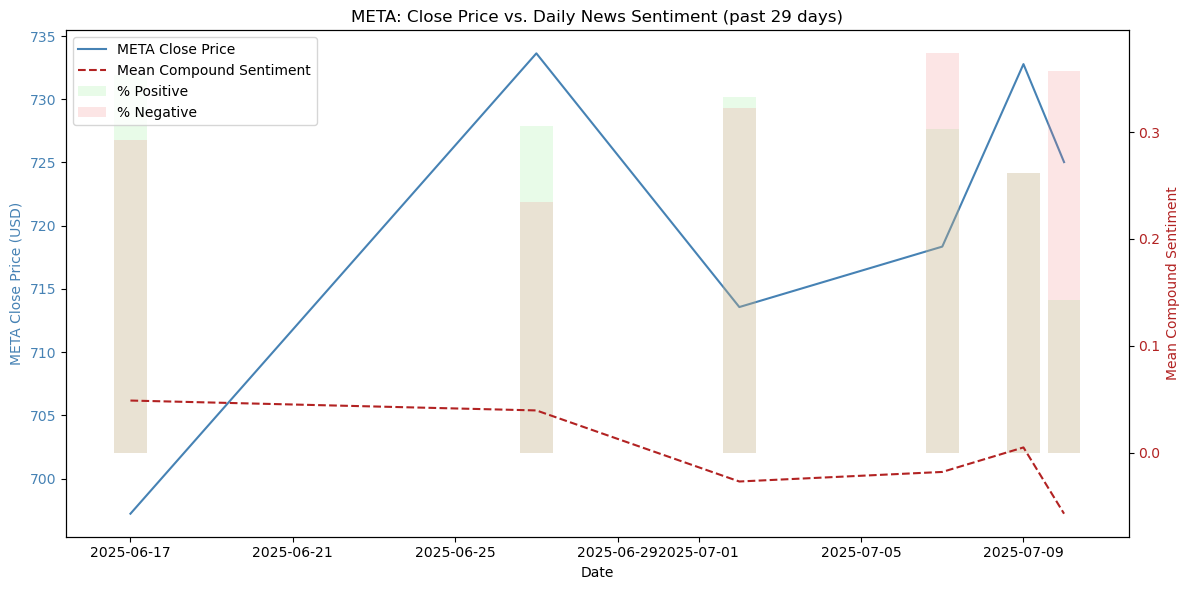

Saved and displayed plot for META: image/META_sentiment_vs_price.png
NVDA Merged Data Date Range: 2025-06-17 00:00:00 to 2025-07-09 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-17  144.119995       0.066332      0.281250           96
1 2025-06-24  147.899994       0.157216      0.452632           95
2 2025-06-25  154.309998       0.126176      0.381443           97
3 2025-06-26  155.020004       0.077833      0.330000          100
4 2025-06-27  157.750000       0.142591      0.397959           98
------------------------------------------------------------


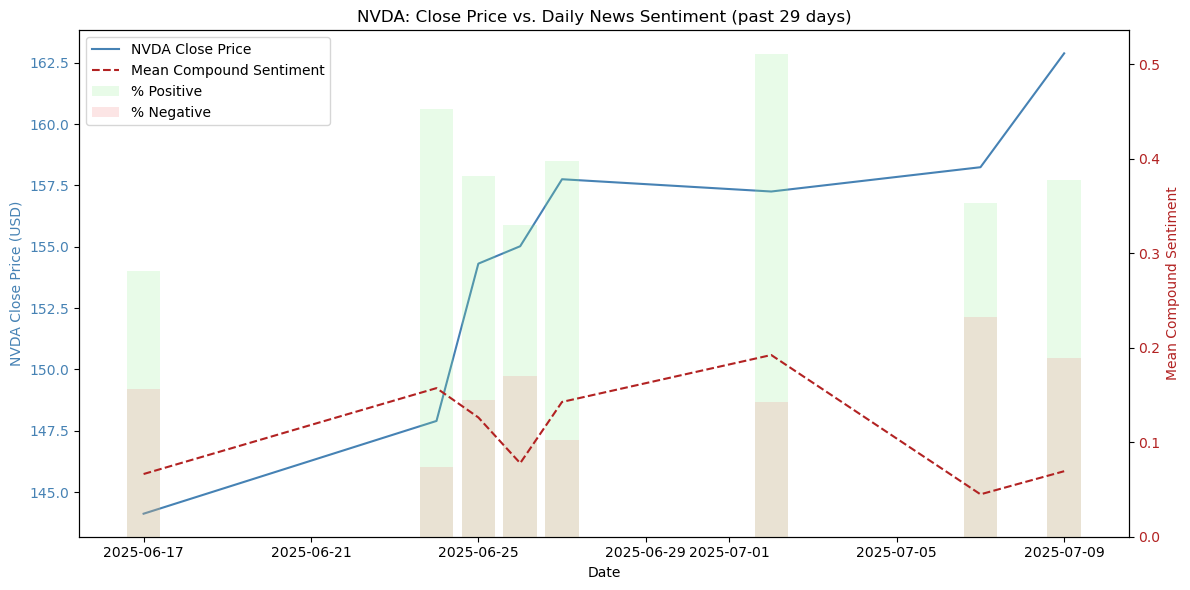

Saved and displayed plot for NVDA: image/NVDA_sentiment_vs_price.png
TSLA Merged Data Date Range: 2025-06-17 00:00:00 to 2025-07-10 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-17  316.350006      -0.045178      0.278351           97
1 2025-06-20  322.160004      -0.003351      0.281250           96
2 2025-06-27  323.630005      -0.042359      0.262626           99
3 2025-07-02  315.649994      -0.070974      0.214286           98
4 2025-07-07  293.940002       0.004103      0.273684           95
------------------------------------------------------------


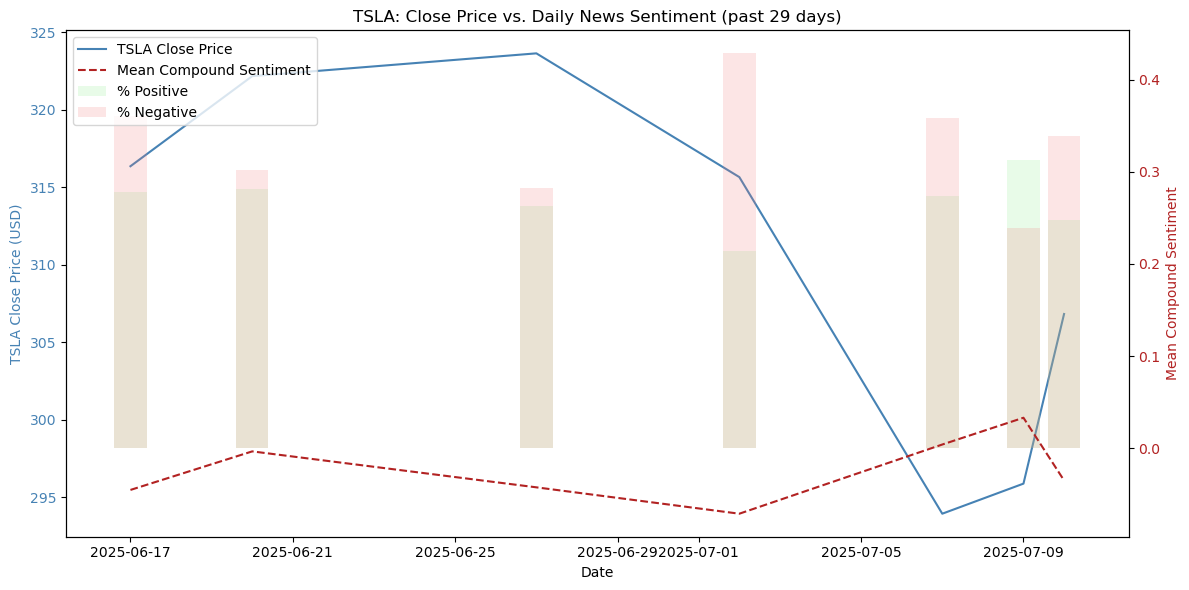

Saved and displayed plot for TSLA: image/TSLA_sentiment_vs_price.png
ORCL Merged Data Date Range: 2025-06-12 00:00:00 to 2025-07-09 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-12  199.860001       0.056777      0.272727           22
1 2025-06-13  215.220001       0.107937      0.450000           80
2 2025-06-16  211.100006       0.110243      0.417910           67
3 2025-06-17  208.179993       0.090311      0.472222           72
4 2025-06-20  205.169998       0.165842      0.509091           55
------------------------------------------------------------


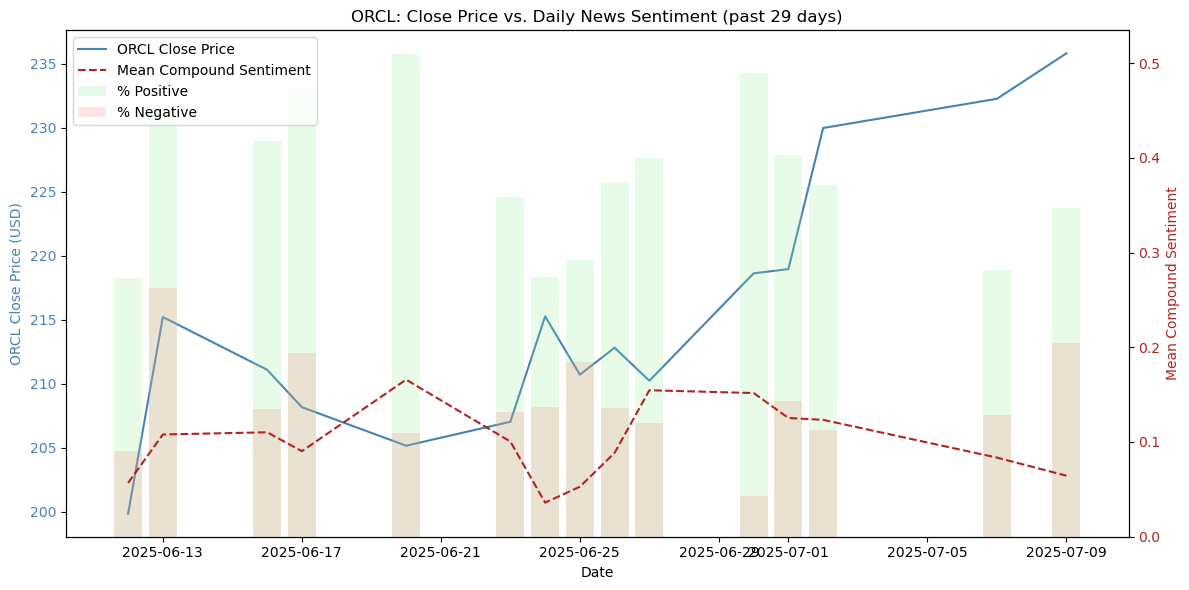

Saved and displayed plot for ORCL: image/ORCL_sentiment_vs_price.png
IBM Merged Data Date Range: 2025-06-12 00:00:00 to 2025-07-10 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-12  281.029999      -0.009000      0.204545           44
1 2025-06-13  277.220001       0.042332      0.333333           60
2 2025-06-16  281.829987       0.104404      0.355556           45
3 2025-06-17  283.049988       0.048085      0.306452           62
4 2025-06-18  283.209991       0.079739      0.390244           41
------------------------------------------------------------


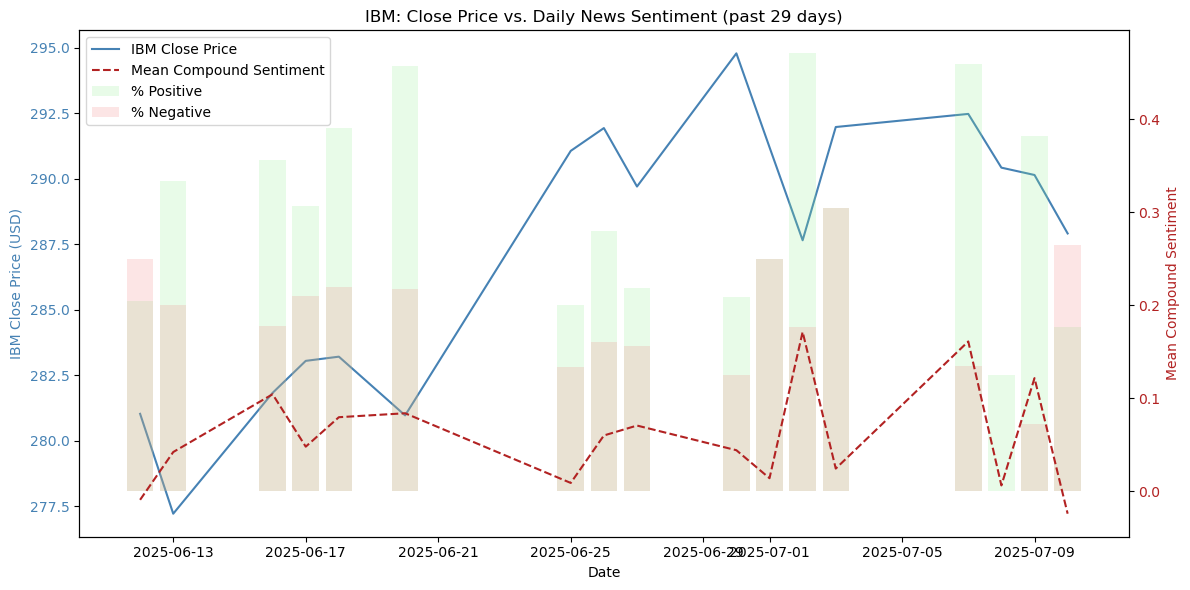

Saved and displayed plot for IBM: image/IBM_sentiment_vs_price.png
CRM Merged Data Date Range: 2025-06-12 00:00:00 to 2025-07-10 00:00:00
        date       Close  mean_compound  pct_positive  n_headlines
0 2025-06-12  266.487427       0.176849      0.410256           39
1 2025-06-13  257.990875       0.178229      0.460317           63
2 2025-06-16  263.462219       0.122563      0.444444           54
3 2025-06-17  262.343994       0.094966      0.424658           73
4 2025-06-20  260.630005       0.163444      0.451613           62
------------------------------------------------------------


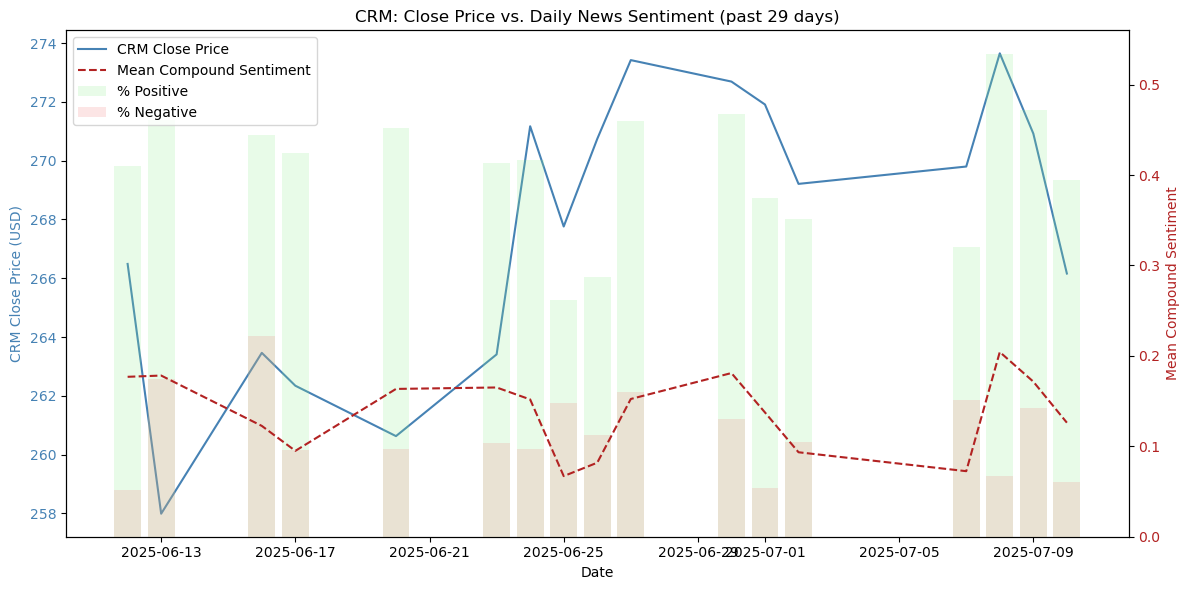

Saved and displayed plot for CRM: image/CRM_sentiment_vs_price.png


In [49]:
import matplotlib.pyplot as plt
import os

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'ORCL', 'IBM', 'CRM']

sent_path = "data/news/daily_sentiment_summary_et.csv"
sent_df = pd.read_csv(sent_path)
sent_df['date'] = pd.to_datetime(sent_df['date'])

for ticker in TICKERS:
    price_path = f"data/engineered/{ticker}_engineered.csv"
    if not os.path.exists(price_path):
        print(f"[Skip] Price file not found: {price_path}")
        continue

    tmp_df = pd.read_csv(price_path, nrows=1)
    date_col = "date" if "date" in tmp_df.columns else "Date"
    price_df = pd.read_csv(price_path, parse_dates=[date_col])
    price_df = price_df.rename(columns={date_col: "date"})

    merged_df = pd.merge(
        price_df,
        sent_df[sent_df['ticker'] == ticker],
        on='date',
        how='inner'
    )
    if merged_df.empty:
        print(f"[Skip] No overlapping dates for {ticker}")
        continue
    merged_df = merged_df.sort_values('date').reset_index(drop=True)

    print(f"{ticker} Merged Data Date Range: {merged_df['date'].min()} to {merged_df['date'].max()}")
    print(merged_df[['date', 'Close', 'mean_compound', 'pct_positive', 'n_headlines']].head())
    print('-' * 60)

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(merged_df['date'], merged_df['Close'], label=f"{ticker} Close Price", color="steelblue")
    ax1.set_xlabel("Date")
    ax1.set_ylabel(f"{ticker} Close Price (USD)", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")

    ax2 = ax1.twinx()
    ax2.plot(merged_df['date'], merged_df['mean_compound'], label="Mean Compound Sentiment", color="firebrick", linestyle="--")
    ax2.set_ylabel("Mean Compound Sentiment", color="firebrick")
    ax2.tick_params(axis="y", labelcolor="firebrick")

    ax2.bar(merged_df['date'], merged_df['pct_positive'],
            alpha=0.2, color="lightgreen", label="% Positive")
    ax2.bar(merged_df['date'], merged_df['pct_negative'],
            alpha=0.2, color="lightcoral", label="% Negative")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.title(f"{ticker}: Close Price vs. Daily News Sentiment (past 29 days)")
    plt.tight_layout()
    plt.savefig(f"image/{ticker}_sentiment_vs_price.png")
    plt.show()
    plt.close()
    print(f"Saved and displayed plot for {ticker}: image/{ticker}_sentiment_vs_price.png")